<a href="https://colab.research.google.com/github/ajaykumar080286/MachineLearning/blob/main/29_perceptron_trick.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification

In [89]:
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

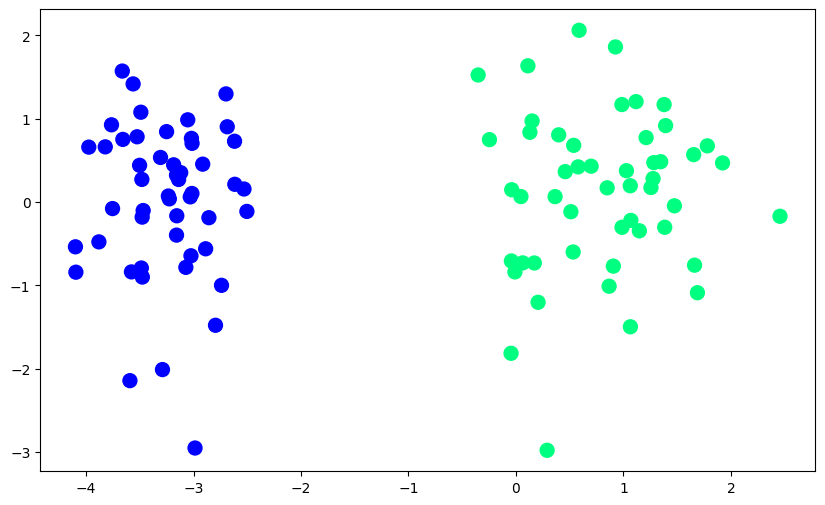

In [90]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [91]:
def preceptron(X,y):

  lr=0.1
  epochs=500

  X=np.insert(X,0,1,axis=1)
  weights=np.ones(X.shape[1])

  for i in range(epochs):

    idx=np.random.randint(0,X.shape[0])
    y_hat=step(np.dot(X[idx],weights))
    weights=weights+lr*(y[idx]-y_hat)*X[idx]

  return weights[0],weights[1:]

In [92]:
def step(z):
  return 1 if z>0 else 0

In [93]:
intercept_,coef_=preceptron(X,y)

In [94]:
intercept_

np.float64(1.3000000000000003)

In [95]:
coef_[0]

np.float64(1.0534361708402222)

In [96]:
coef_[1]

np.float64(0.22215119727529098)

In [97]:
m=-(coef_[0]/coef_[1])
m

np.float64(-4.741978363208182)

In [98]:
b=-(intercept_/coef_[1])
b

np.float64(-5.851870329508209)

In [99]:
X_input=np.linspace(-3,3,100)
y_imput=m*X_input+b

(-3.0, 2.0)

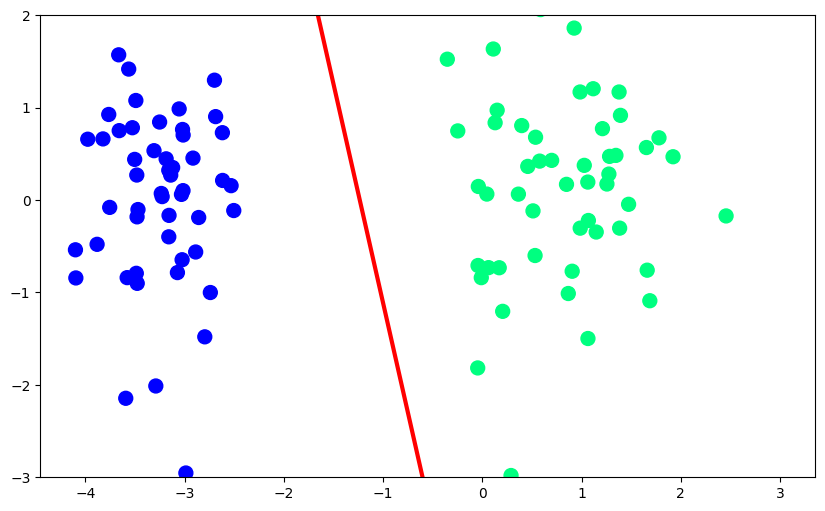

In [100]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.plot(X_input,y_imput,color='red',linewidth=3)
plt.ylim(-3,2)

In [101]:
lr=LogisticRegression()
lr.fit(X,y)

LogisticRegression()

In [102]:
coef_=lr.coef_
coef_

array([[2.36679363, 0.02300492]])

In [103]:
intercept_=lr.intercept_
intercept_

array([3.13571596])

In [104]:
a=coef_[0][0]

In [105]:
b=coef_[0][1]

In [106]:
c=intercept_

In [107]:
m=-(a/b)
m

np.float64(-102.88205179540364)

In [108]:
d=-(c/b)
d

array([-136.30630349])

In [109]:
y_input1=m*X_input+d

(-3.0, 2.0)

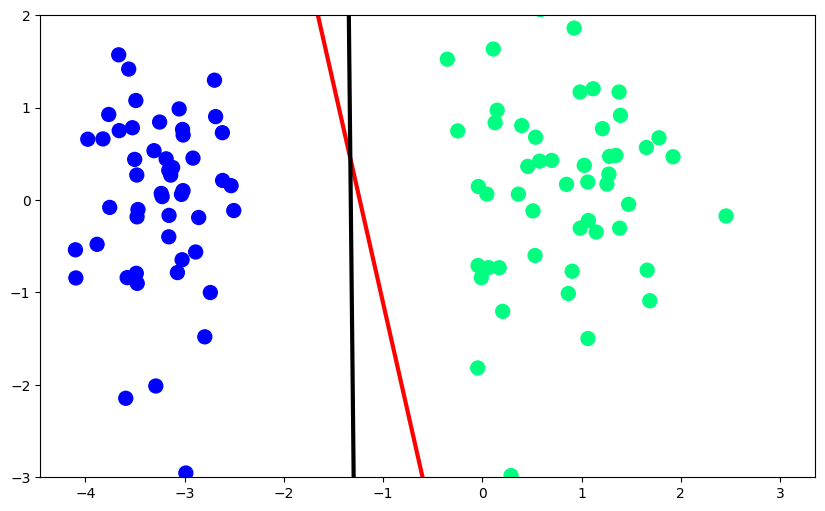

In [110]:
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
plt.plot(X_input,y_imput,color='red',linewidth=3)
plt.plot(X_input,y_input1,color='black',linewidth=3)

plt.ylim(-3,2)

In [134]:
def perceptron(X,y):

    m = []
    b = []

    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1

    for i in range(200):
        j = np.random.randint(0,100)
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]

        m.append(-(weights[1]/weights[2]))
        b.append(-(weights[0]/weights[2]))

    return m,b

In [135]:
%matplotlib notebook
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(9,5))

m_values, b_values = perceptron(X, y) # Call the perceptron function and get lists of m and b

x_i = np.arange(-3, 3, 0.1)
y_i = x_i*m_values[0] + b_values[0]
ax.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)
line, = ax.plot(x_i, x_i*m_values[0] + b_values[0] , 'r-', linewidth=2)
plt.ylim(-3,3)
def update(i):
    label = 'epoch {0}'.format(i + 1)
    line.set_ydata(x_i*m_values[i] + b_values[i])
    ax.set_xlabel(label)
    # return line, ax

anim = FuncAnimation(fig, update, repeat=True, frames=200, interval=100)
#anim.save("perceptron.gif", writer=animation.PillowWriter(fps=10))
plt.show()

<IPython.core.display.Javascript object>

/usr/local/lib/python3.12/dist-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(
